In [1]:
import os
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import glob

from hbn.visualization import visualize

import warnings
warnings.filterwarnings("ignore")

%load_ext autoreload
%autoreload 2

%matplotlib inline

#pio.renderers.default = 'iframe'
import plotly.io as pio
pio.renderers.default='notebook'

## Check ADHD age models

In [12]:
# check AGE models
from hbn.models.predictive_modeling import check_models

dirn = '/Users/maedbhking/Documents/hbn_data/models'
filter_model = 'adhd-age-models'
diagnosis_file = '/Users/maedbhking/Documents/hbn_data/Clinical_Diagnosis_Demographics.csv'

# hard code model diretory
df_all = check_models(dirn=dirn, 
            diagnosis_file=diagnosis_file,
            filter=f'*{filter_model}/*')
  
df_all['participant_group'] = df_all['sex'] + '_' + df_all['age']

In [13]:
# set plotting style
visualize.plotting_style()

## Age

<Axes: xlabel='age', ylabel='roc_auc_score'>

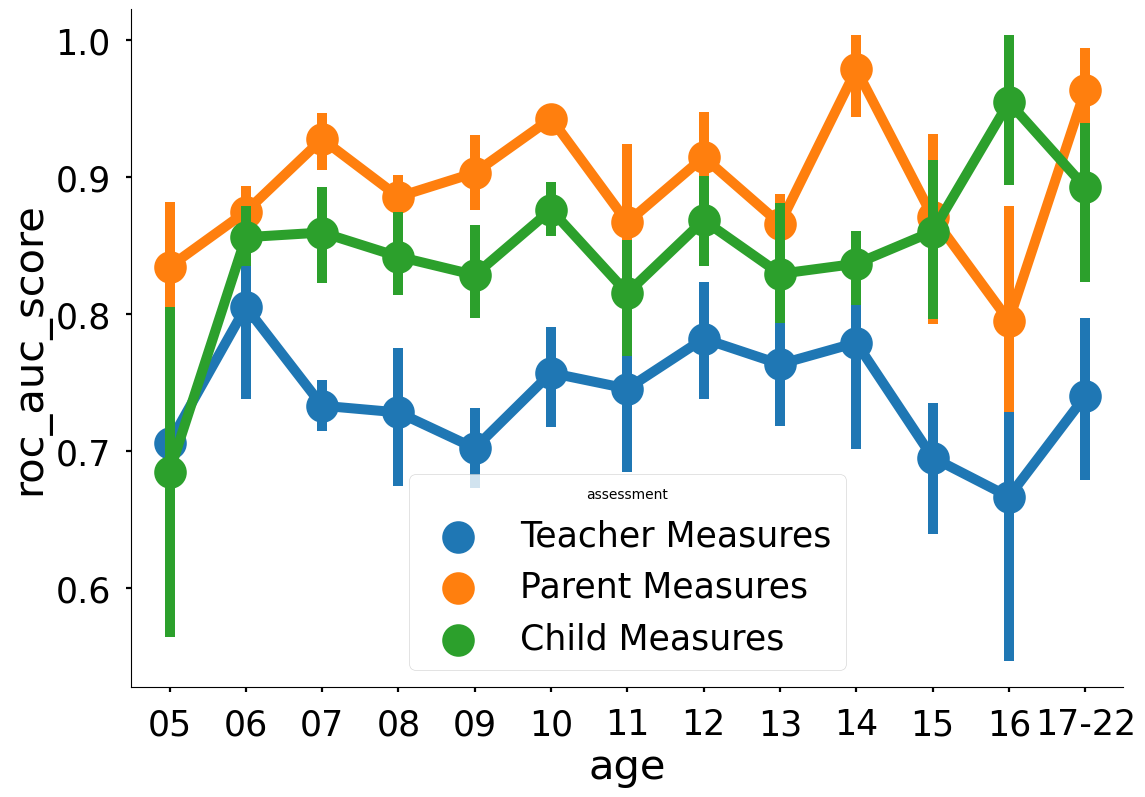

In [14]:
ages_to_keep = ['05', '06', '07', '08', '09', '10', '11', '12', '13', '14', '15', '16', '17-22']

df1 = df_all[(df_all['sex'].isin(['all'])) &
             (df_all['data']=='data') &
             (df_all['age'].isin(ages_to_keep)) &
             (df_all['assessment'].isin(['Parent Measures', 'Child Measures', 'Teacher Measures']))
            ]

sns.pointplot(x='age', y='roc_auc_score', hue='assessment', data=df1, order=sorted(df1['age'].unique()))

<Axes: xlabel='age', ylabel='roc_auc_score'>

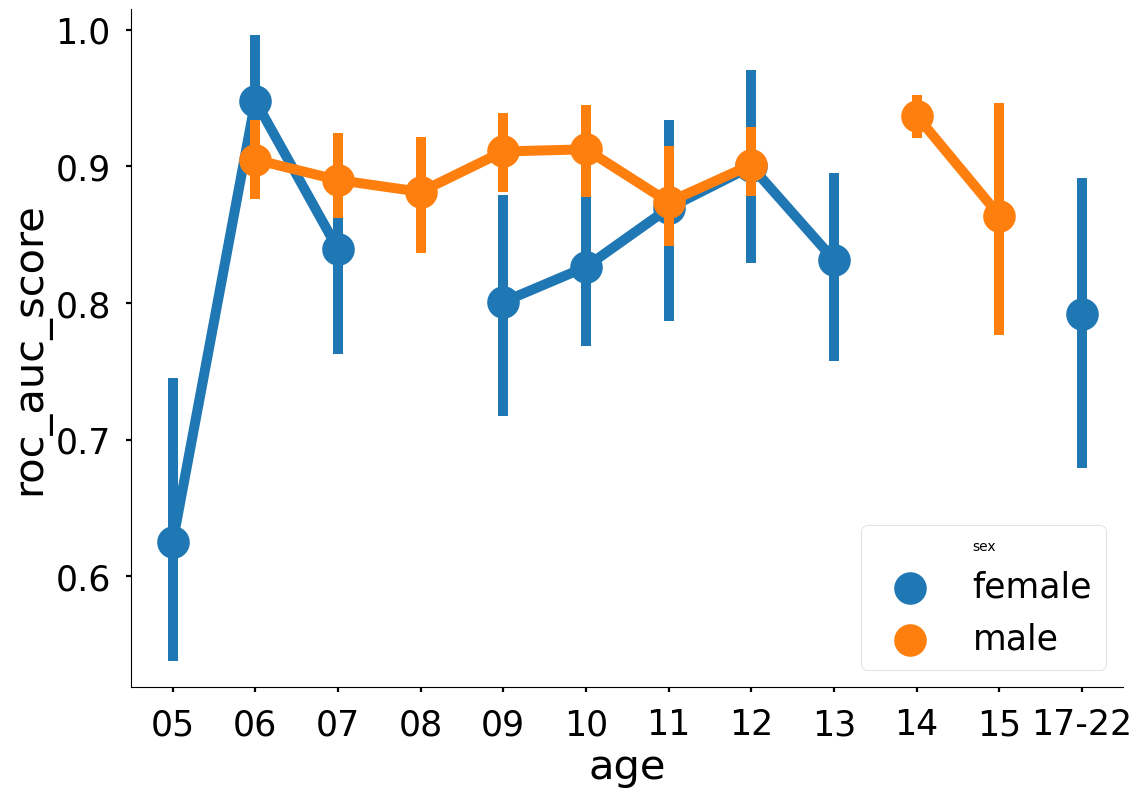

In [15]:
ages_to_keep = ['05', '06', '07', '08', '09', '10', '11', '12', '13', '14', '15', '16', '17-22']


df1 = df_all[(df_all['sex'].isin(['male', 'female'])) &
             (df_all['data']=='data') &
             (df_all['age'].isin(ages_to_keep)) &
             (df_all['assessment']=='all')
            ]

sns.pointplot(x='age', y='roc_auc_score', hue='sex', data=df1, order=sorted(df1['age'].unique()))

<Axes: xlabel='age', ylabel='roc_auc_score'>

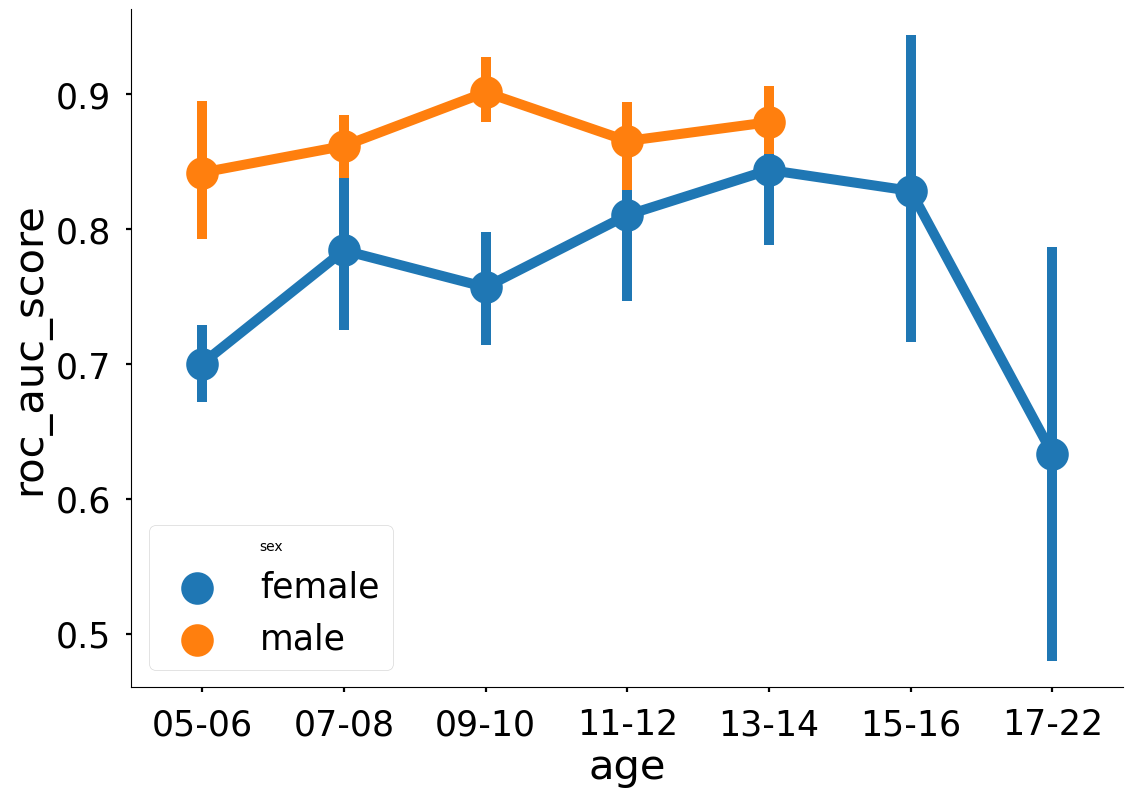

In [16]:
ages_to_keep = ['05-06', '07-08', '09-10', '11-12', '13-14', '15-16', '17-22']


df1 = df_all[(df_all['sex'].isin(['male', 'female'])) &
             (df_all['data']=='data') &
             (df_all['age'].isin(ages_to_keep)) &
             (df_all['assessment']=='Child Measures')
            ]

sns.pointplot(x='age', y='roc_auc_score', hue='sex', data=df1, order=sorted(df1['age'].unique()))

## Check ADHD models (against all diagnoses)

In [17]:
# check ADHD models
from hbn.models.predictive_modeling import check_models

dirn = '/Users/maedbhking/Documents/hbn_data/models'
filter_model = 'adhd-models'
diagnosis_file = '/Users/maedbhking/Documents/hbn_data/Clinical_Diagnosis_Demographics.csv'

# hard code model diretory
df_all = check_models(dirn=dirn, 
            diagnosis_file=diagnosis_file,
            filter=f'*{filter_model}/*')
  
df_all['participant_group'] = df_all['sex'] + '_' + df_all['age']
df_all['category_new'] = df_all['category'].str.replace('ADHD_', '').str.replace('_ADHD', '')


## Classification of ADHD for males and females (across different diagnoses)

## Classifying ADHD from other diagnoses

In these models, ADHD is classified from a number of diagnoses (ASD, Depression, No Diagnosis etc.).
* Parent Measures: Males are always etter classified than females except for ADHD/ASD in which females are better classified
* Child Measures: same result for child measurse, except that females are only slightly better than males when classifying ADHD/ASD
* Teacher Measures: no sig. difference between males and females for both classifications except ADHD/ASD where females are better classified

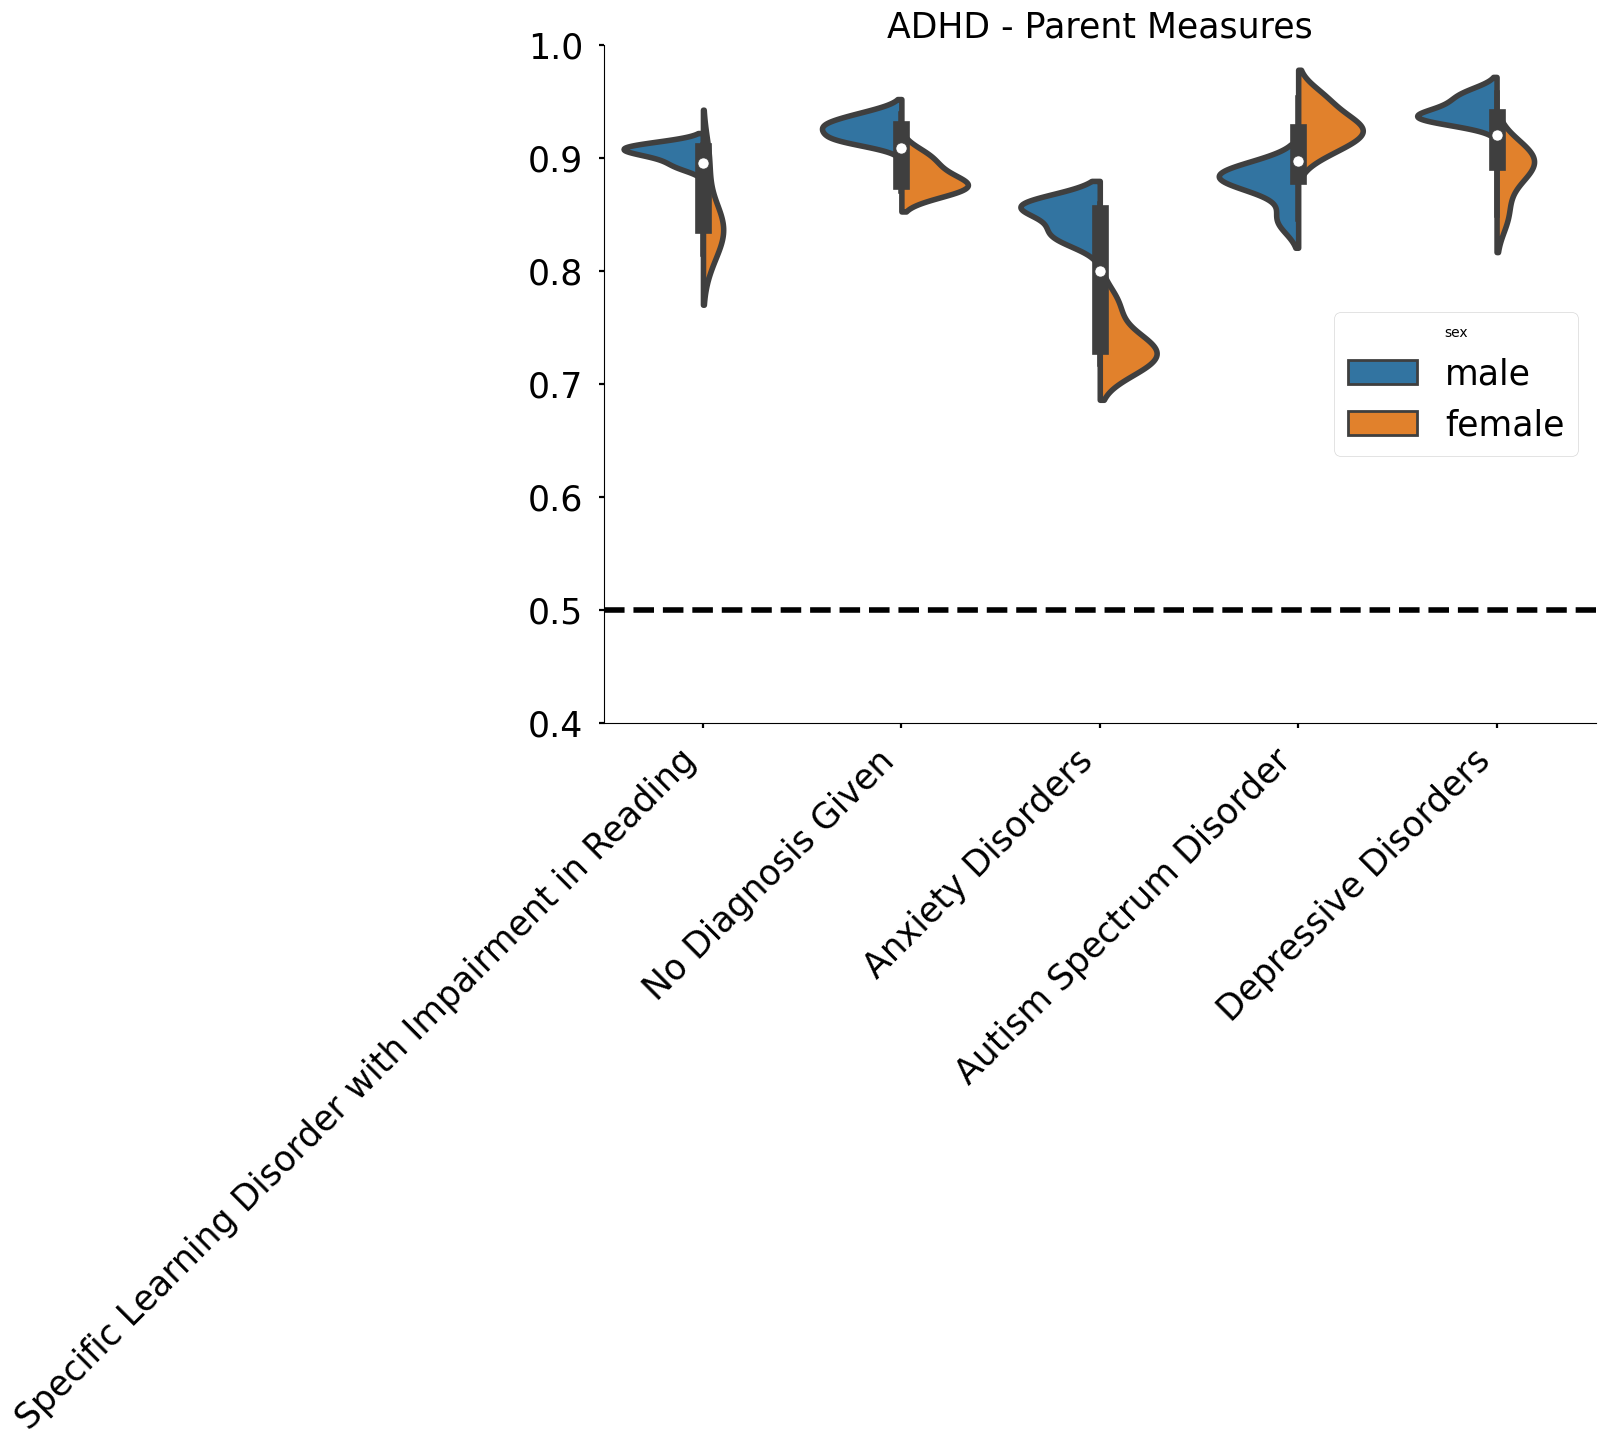

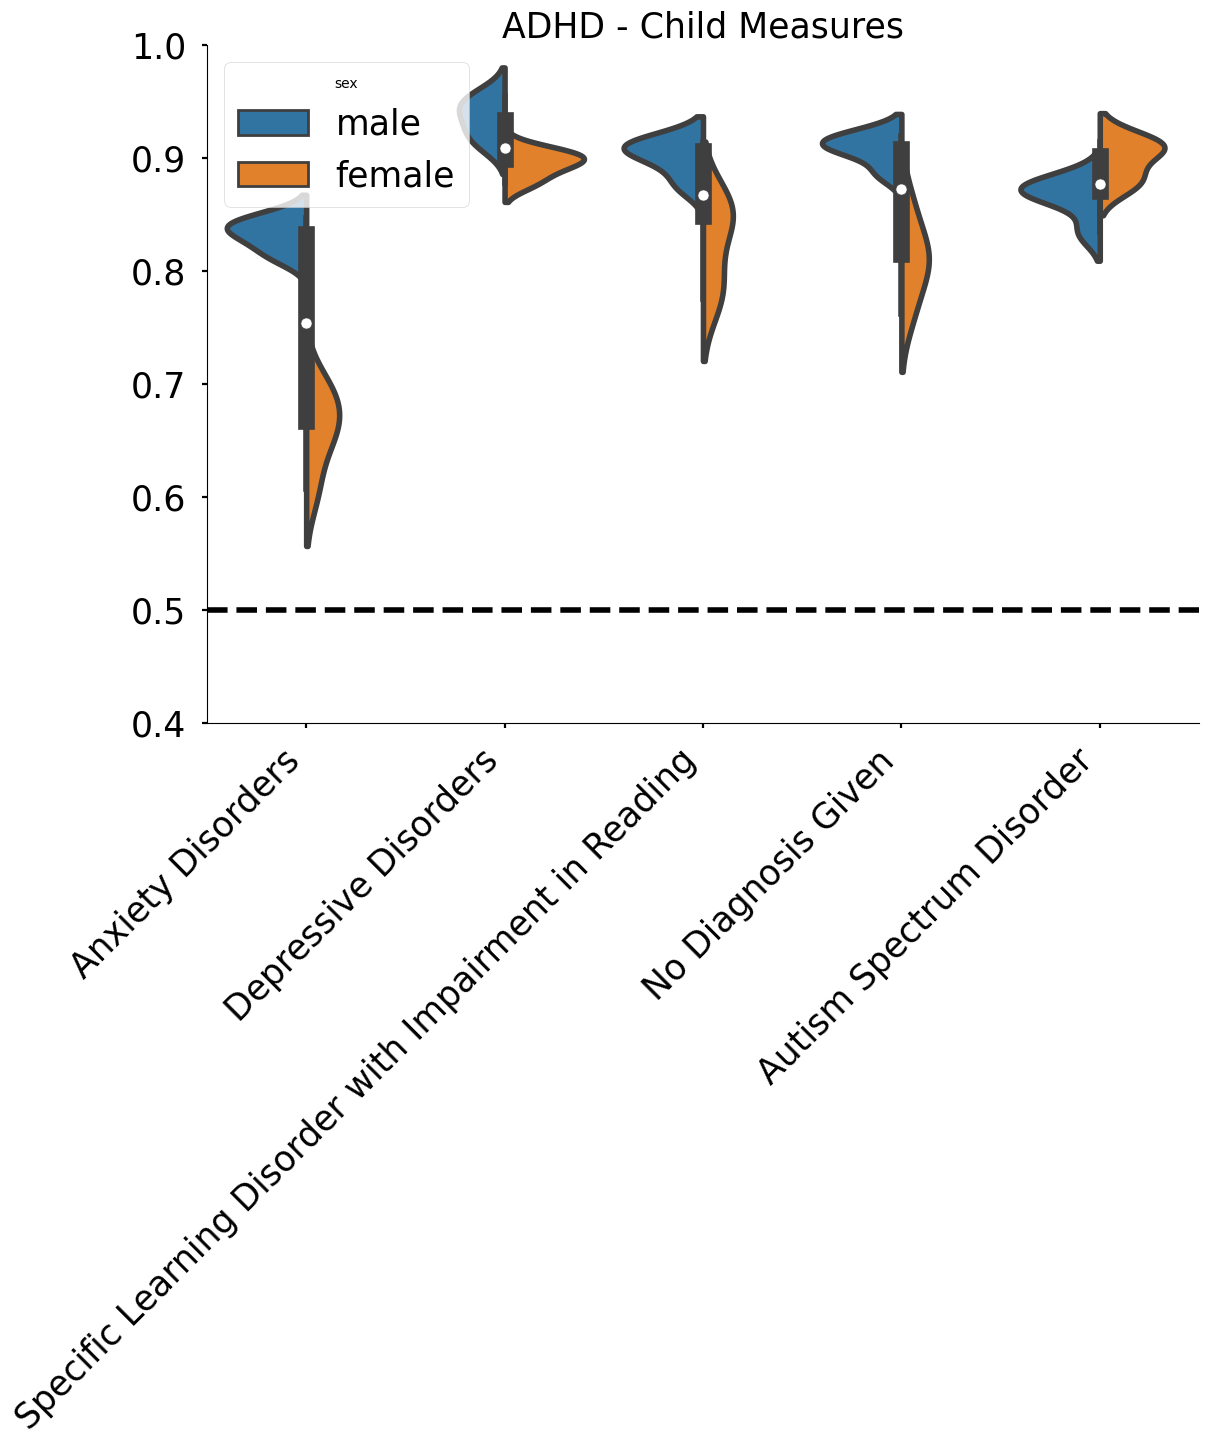

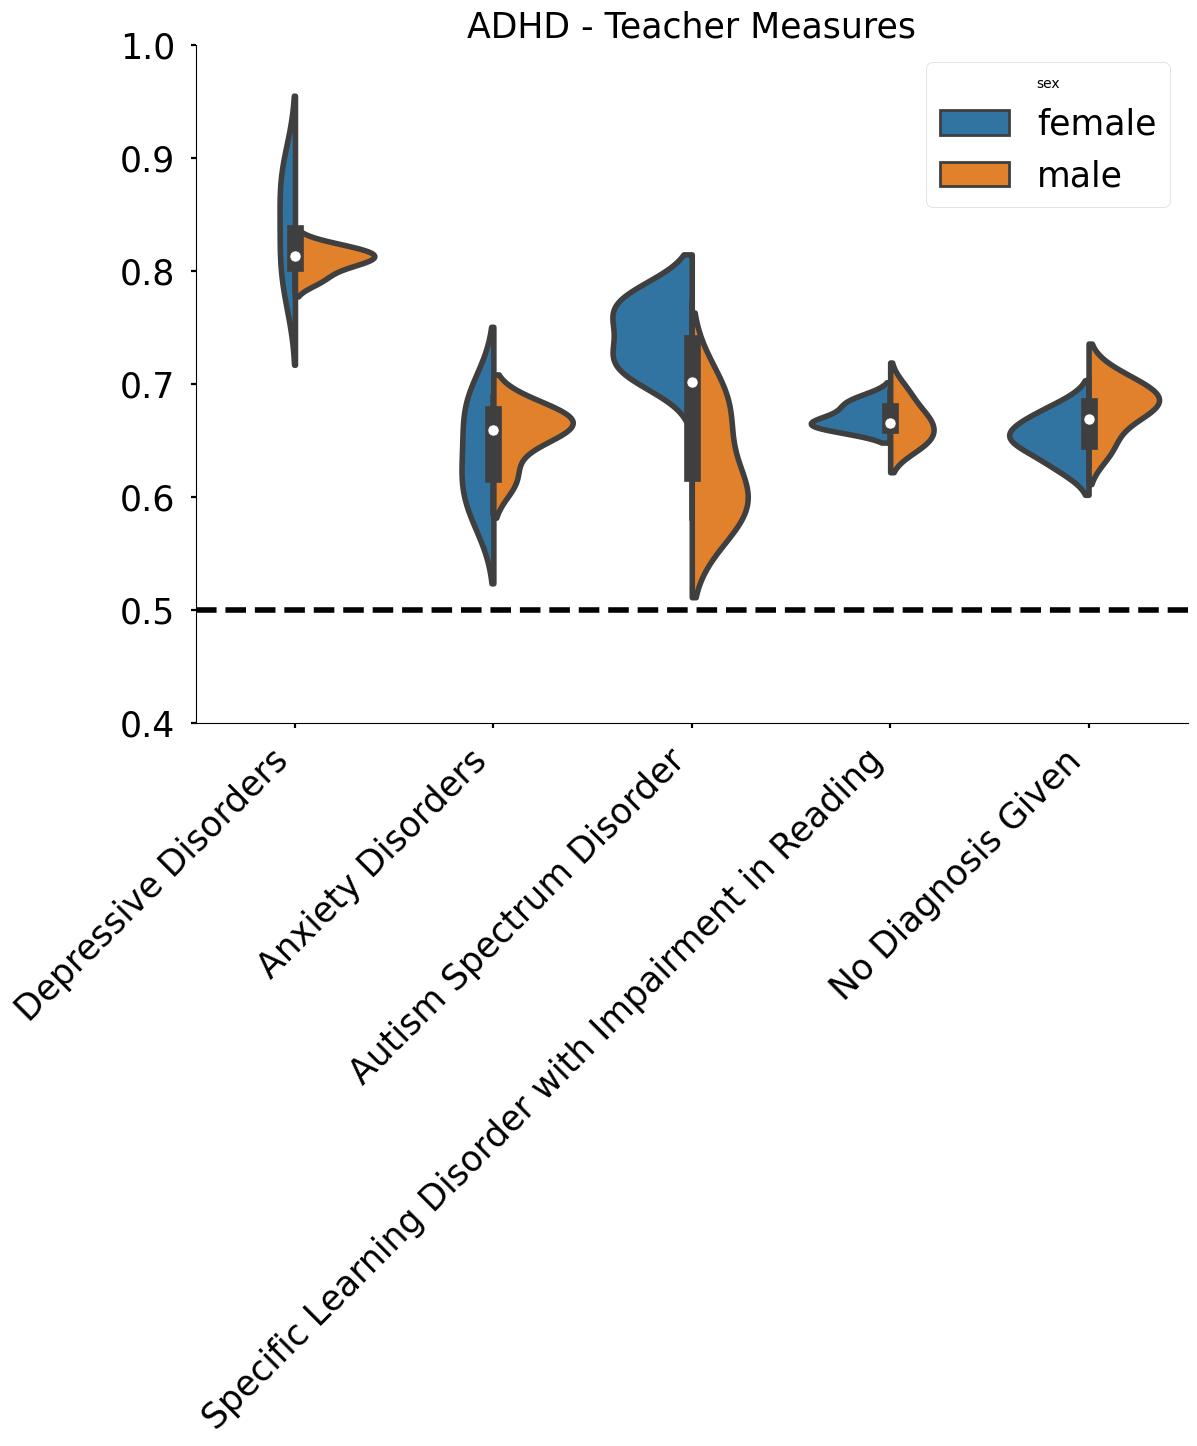

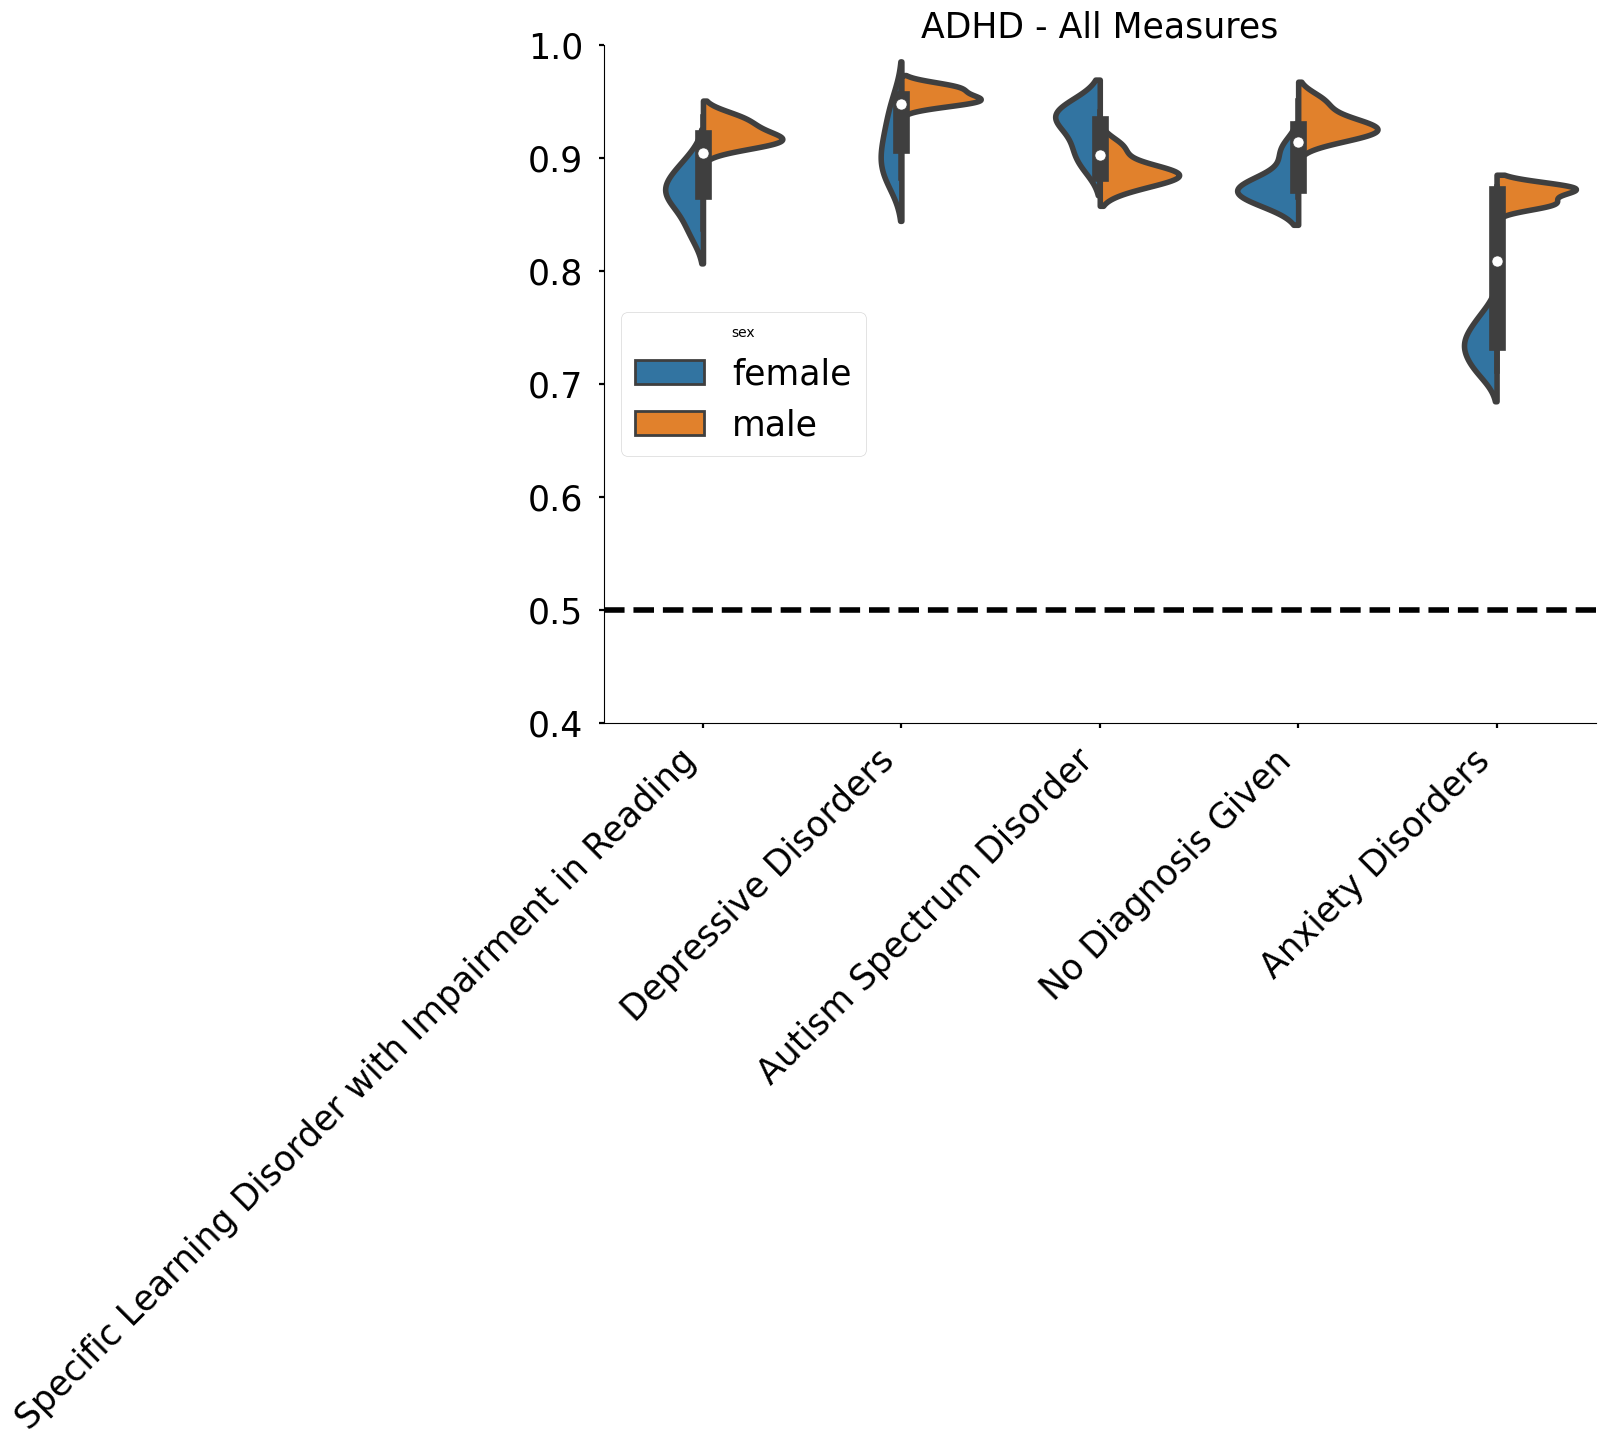

In [18]:
to_keep = ['Depressive Disorders', 'Anxiety Disorders', 'Autism Spectrum Disorder', 
           'Specific Learning Disorder with Impairment in Reading', 'No Diagnosis Given']

# PARENT MEASURES
df1 = df_all[(df_all['sex'].isin(['male', 'female'])) &
             (df_all['data']=='data') &
             (df_all['assessment']=='Parent Measures') &
             (df_all['category_new'].isin(to_keep))
            ].reset_index(drop=True)


ax = sns.violinplot(x='category_new', y='roc_auc_score', hue='sex', split=True, data=df1)
plt.xticks(rotation=45, ha='right')
ax.set_xlabel('')
ax.set_ylabel('')
ax.set_title('ADHD - Parent Measures')
plt.axhline(y=0.5, color='k', linestyle='--')
ax.set_ylim([0.4, 1])
plt.show()

# CHILD MEASURES
df1 = df_all[(df_all['sex'].isin(['male', 'female'])) &
             (df_all['data']=='data') &
             (df_all['assessment']=='Child Measures') &
             (df_all['category_new'].isin(to_keep))
            ].reset_index(drop=True)

ax = sns.violinplot(x='category_new', y='roc_auc_score', hue='sex', split=True, data=df1)
plt.xticks(rotation=45, ha='right')
ax.set_xlabel('')
ax.set_ylabel('')
ax.set_title('ADHD - Child Measures')
plt.axhline(y=0.5, color='k', linestyle='--')
ax.set_ylim([0.4, 1])
plt.show()

# TEACHER MEASURES
df1 = df_all[(df_all['sex'].isin(['male', 'female'])) &
             (df_all['data']=='data') &
             (df_all['assessment']=='Teacher Measures') &
             (df_all['category_new'].isin(to_keep))
            ].reset_index(drop=True)

ax = sns.violinplot(x='category_new', y='roc_auc_score', hue='sex', split=True, data=df1)
plt.xticks(rotation=45, ha='right')
ax.set_xlabel('')
ax.set_ylabel('')
ax.set_title('ADHD - Teacher Measures')
plt.axhline(y=0.5, color='k', linestyle='--')
ax.set_ylim([0.4, 1])
plt.show()

# ALL MEASURES
df1 = df_all[(df_all['sex'].isin(['male', 'female'])) &
             (df_all['data']=='data') &
             (df_all['assessment']=='all') &
             (df_all['category_new'].isin(to_keep))
            ].reset_index(drop=True)

ax = sns.violinplot(x='category_new', y='roc_auc_score', hue='sex', split=True, data=df1)
plt.xticks(rotation=45, ha='right')
ax.set_xlabel('')
ax.set_ylabel('')
ax.set_title('ADHD - All Measures')
plt.axhline(y=0.5, color='k', linestyle='--')
ax.set_ylim([0.4, 1])
plt.show()

## Check ADHD Secondlevel Models

In [18]:
# check AGE models
from hbn.models.predictive_modeling import check_models

dirn = '/Users/maedbhking/Documents/hbn_data/models'
filter_model = 'adhd-secondlevel-models'
diagnosis_file = '/Users/maedbhking/Documents/hbn_data/Clinical_Diagnosis_Demographics.csv'

# hard code model diretory
df_all = check_models(dirn=dirn, 
            diagnosis_file=diagnosis_file,
            filter=f'*{filter_model}/*')
  
df_all['participant_group'] = df_all['sex'] + '_' + df_all['age']

In [23]:
tmp = pd.read_csv(os.path.join(dirn, filter_model, '2023-06-08_17-27-21-8', 'classifier-feature_importance.csv'))

In [37]:
tmp.sort_values(by='feature_probabilities_rank_order', ascending=False)

,feature_names_rank_order,feature_probabilities_rank_order,feature_names_common,feature_probabilities_common,feature_sum,feature_names_sum,top_features,clf,feature_names,participants,target,features,assessment,domains,measures,abbrevs,model
0,"numeric__SympChck,CSC_51P",1.0,"numeric__SympChck,CSC_51P",1.0,2.275601,"numeric__SympChck,CSC_51P",False,DecisionTreeClassifier,"numeric__ACE_BRT,ACE_BRT_response_time_Right_t...",NDARAC850DCN-NDARAD232HVV-NDARAE301XTM-NDARAE3...,DX_01_Cat_new_binarize,all-all,all,all,all,all,20230608T212818.009119
1,"numeric__CBCL,CBCL_08",1.0,"numeric__CBCL,CBCL_08",1.0,0.777261,"numeric__CBCL,CBCL_08",False,DecisionTreeClassifier,"numeric__ACE_Flanker,ACE_Flanker_late_response...",NDARAC850DCN-NDARAD232HVV-NDARAE301XTM-NDARAE3...,DX_01_Cat_new_binarize,all-all,all,all,all,all,20230608T212818.009119
2,"numeric__PreInt_TxHx,Past_DX",1.0,"numeric__PreInt_TxHx,Past_DX",1.0,0.364541,"numeric__PreInt_TxHx,Past_DX",False,DecisionTreeClassifier,"numeric__ACE_SAAT,ACE_SAAT_response_window_Sus...",NDARAC850DCN-NDARAD232HVV-NDARAE301XTM-NDARAE3...,DX_01_Cat_new_binarize,all-all,all,all,all,all,20230608T212818.009119
3,"numeric__ASSQ,ASSQ_Total",0.6,"numeric__ASSQ,ASSQ_Total",0.6,0.216742,"numeric__ASSQ,ASSQ_Total",True,DecisionTreeClassifier,"numeric__CTOPP,CTOPP_Valid",NDARAC850DCN-NDARAD232HVV-NDARAE301XTM-NDARAE3...,DX_01_Cat_new_binarize,all-all,all,all,all,all,20230608T212818.009119
6,"numeric__RBS,RBS_24",0.6,"numeric__RBS,RBS_24",0.6,0.134875,"numeric__RBS,RBS_24",False,DecisionTreeClassifier,"numeric__bia_final,BIA_DEE",NDARAC850DCN-NDARAD232HVV-NDARAE301XTM-NDARAE3...,DX_01_Cat_new_binarize,all-all,all,all,all,all,20230608T212818.009119
16,"numeric__YSR,YSR_85",0.6,"numeric__YSR,YSR_85",0.6,0.048673,"numeric__bia_final,BIA_DEE",False,DecisionTreeClassifier,"numeric__SAS,SAS_02",NDARAC850DCN-NDARAD232HVV-NDARAE301XTM-NDARAE3...,DX_01_Cat_new_binarize,all-all,all,all,all,all,20230608T212818.009119
26,"numeric__ACE_Flanker,ACE_Flanker_late_response...",0.4,"numeric__ACE_SAAT,ACE_SAAT_response_window_Sus...",0.6,0.000000,"numeric__ACE_SAAT,ACE_SAAT_response_window_Sus...",False,DecisionTreeClassifier,"numeric__PCIAT,PCIAT_18",NDARAC850DCN-NDARAD232HVV-NDARAE301XTM-NDARAE3...,DX_01_Cat_new_binarize,all-all,all,all,all,all,20230608T212818.009119
25,"numeric__ACE_SAAT,ACE_SAAT_response_window_Sus...",0.4,"numeric__ACE_SAAT,ACE_SAAT_response_window_Sus...",0.4,0.002503,"numeric__ACE_Flanker,ACE_Flanker_late_response...",False,DecisionTreeClassifier,"numeric__APQ_P,APQ_P_Total",NDARAC850DCN-NDARAD232HVV-NDARAE301XTM-NDARAE3...,DX_01_Cat_new_binarize,all-all,all,all,all,all,20230608T212818.009119
21,"numeric__SAS,SAS_02",0.4,"numeric__SAS,SAS_02",0.4,0.029738,"numeric__APQ_P,APQ_P_Total",False,DecisionTreeClassifier,"numeric__PreInt_DevHx,skill_age_03",NDARAC850DCN-NDARAD232HVV-NDARAE301XTM-NDARAE3...,DX_01_Cat_new_binarize,all-all,all,all,all,all,20230608T212818.009119
18,"numeric__SRS_Pre,SRS_P_37",0.4,"numeric__SRS_Pre,SRS_P_37",0.4,0.035486,"numeric__ACE_BRT,ACE_BRT_response_time_Right_t...",False,DecisionTreeClassifier,"numeric__SRS_Pre,SRS_P_37",NDARAC850DCN-NDARAD232HVV-NDARAE301XTM-NDARAE3...,DX_01_Cat_new_binarize,all-all,all,all,all,all,20230608T212818.009119
